#Load Libraries

In [34]:
import os
import numpy as np
import cv2
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
proj_dir='/content/drive/MyDrive/LUMBAR_SPINE/'
X_train=np.load(proj_dir+'ROI_train.npy',allow_pickle = True)
X_test=np.load(proj_dir+'ROI_test.npy', allow_pickle = True)

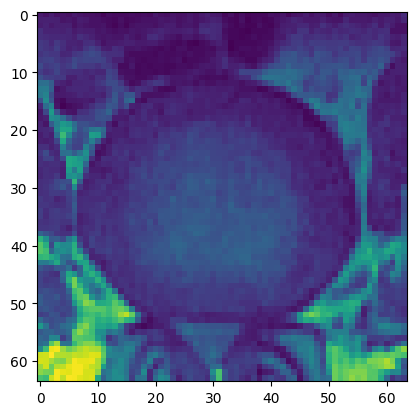

In [37]:
img=X_train[10]
plt.imshow(img)
plt.show()

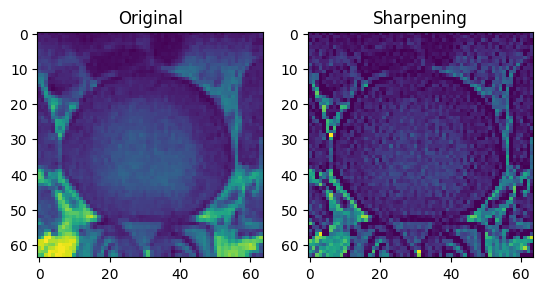

In [38]:
# Load the image
image = img

#Plot the original image
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image)

kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])# Create the sharpening kernel


sharpened_image = cv2.filter2D(image, -1, kernel)# Sharpen the image


#Plot the sharpened image
plt.subplot(1, 2, 2)
plt.title("Sharpening")
plt.imshow(sharpened_image)
plt.show()


In [39]:
def img_enhancement(image):
  kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

  # Sharpen the image
  sharpened_image = cv2.filter2D(image, -1, kernel)
  return (sharpened_image)

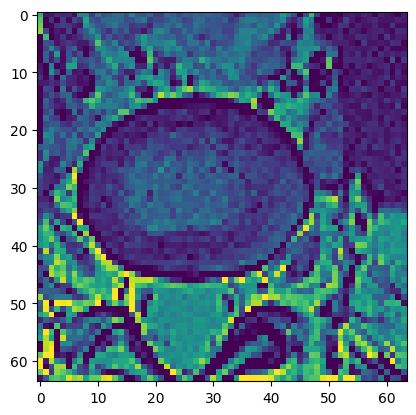

In [40]:
plt.imshow(img_enhancement(X_train[0]))
plt.show()

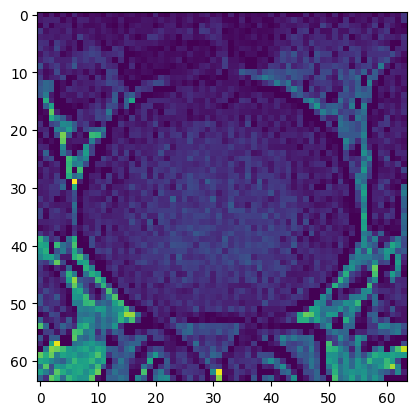

In [41]:
plt.imshow(img_enhancement(X_train[10]))
plt.show()

In [42]:
###enhance train images###
X_train_enh=[]
for img in X_train:
  X_train_enh.append(img_enhancement(img))


###enhance test images###
X_test_enh=[]
for img in X_test:
  X_test_enh.append(img_enhancement(img))
X_train_enh=np.array(X_train_enh)
X_test_enh=np.array(X_test_enh)

In [43]:
len(X_train_enh),len(X_test_enh)

(1390, 155)

In [44]:
##save data##
np.save(proj_dir+'ENH_train.npy', X_train_enh)
np.save(proj_dir+'ENH_test.npy', X_test_enh)